# Ensemble Methods

## What Is an Ensemble?

An **ensemble** is a collection of models whose predictions are combined to produce a final output that is better than any individual model alone. The core insight is borrowed from statistics:

> *Many imperfect models, combined wisely, outperform a single perfect-looking model.*

The reason this works comes down to the **bias-variance tradeoff**. Individual models make errors in two ways — bias (systematic wrong assumptions) and variance (sensitivity to noise in training data). Different ensemble strategies attack these two sources of error differently.

### The Three Main Ensemble Strategies

| Strategy | Core Idea | Reduces | Example Algorithms |
|---|---|---|---|
| **Bagging** | Train models in parallel on random subsets | Variance | Random Forest |
| **Boosting** | Train models sequentially, each fixing previous errors | Bias | XGBoost, AdaBoost |
| **Stacking** | Train a meta-model on the outputs of base models | Both | Stacked Generalization |

Random Forest is a **bagging** ensemble of Decision Trees.

# Random Forest

## What Is Random Forest?

Random Forest is an ensemble algorithm that builds **many Decision Trees** and combines their predictions. Each tree is trained slightly differently, so they make different errors — and when you average out many different errors, they cancel each other out.

For **classification**, the final prediction is a majority vote across all trees:

$$\hat{y} = \text{mode}\left(T_1(\mathbf{x}),\ T_2(\mathbf{x}),\ \ldots,\ T_n(\mathbf{x})\right)$$

For **regression**, the final prediction is the average:

$$\hat{y} = \frac{1}{n}\sum_{i=1}^{n} T_i(\mathbf{x})$$

Where $T_i(\mathbf{x})$ is the prediction of the $i$-th tree and $n$ is the total number of trees.

## Why Does a Single Decision Tree Fail?

A fully grown Decision Tree has **high variance** — it is extremely sensitive to the specific training data it sees. Change a few data points, and the entire tree structure can change dramatically. The tree memorizes noise as if it were signal.

Random Forest fixes this with two sources of randomness:

- **Bootstrap Sampling** — each tree sees a different random subset of the data
- **Feature Randomness** — each split considers only a random subset of features

These two mechanisms ensure the trees are **diverse**. Diverse errors cancel out when averaged. Correlated errors do not.

## Bootstrap Sampling (Bagging)

Instead of training one tree on the full dataset, each tree in the forest is trained on a **bootstrap sample** — $N$ samples drawn **with replacement** from the original $N$ training points.

Because sampling is done with replacement:

- Some samples appear **multiple times** in a given tree's training set
- Some samples are **never seen** by that tree

The samples that a particular tree never trained on are called **Out-of-Bag (OOB) samples**. This is useful — we can evaluate each tree on its OOB samples to get a free estimate of generalization error, without needing a separate validation set.

This overall strategy of training multiple models on bootstrap samples and averaging their predictions is called **Bagging** (Bootstrap Aggregation).

## Feature Randomness

Bootstrap sampling alone is not enough. If all trees use the same strong features at their root splits, they will still be highly correlated with each other — and correlated errors do not cancel out.

Random Forest adds a second layer of randomness: at **each split**, instead of considering all $p$ features, only a random subset of $m$ features is considered:

$$m = \sqrt{p} \quad \text{(for classification)}$$

$$m = \frac{p}{3} \quad \text{(for regression, as a rule of thumb)}$$

This forces different trees to rely on different features, **decorrelating** the trees from each other. The result is a diverse forest where each tree has learned something slightly different about the data.

## Why It Works: The Variance Reduction Theory

Each individual Decision Tree has high variance but low bias. If we could average infinitely many **independent** trees, the variance would shrink to zero while bias stays the same. Formally, for $n$ independent trees each with variance $\text{Var}(T)$:

$$\text{Var}\left(\text{average}\right) = \frac{\text{Var}(T)}{n}$$

More trees → lower variance → better generalization.

In reality, the trees are not fully independent — they are trained on overlapping bootstrap samples from the same dataset. If the correlation between any two trees is $\rho$, the variance of the average is:

$$\text{Var}\left(\text{average}\right) = \rho \cdot \text{Var}(T) + \frac{1 - \rho}{n} \cdot \text{Var}(T)$$

As $n \to \infty$, the second term vanishes, leaving:

$$\text{Var}\left(\text{average}\right) \to \rho \cdot \text{Var}(T)$$

This is why **reducing correlation** $\rho$ between trees matters so much. Feature randomness directly reduces $\rho$, which is why it is essential and not just a computational shortcut.

## Feature Importance

A useful byproduct of Random Forest is **feature importance** — a ranking of which features contributed most to the predictions. It is computed by measuring how much each feature reduces impurity (Gini or entropy) across all splits across all trees, weighted by the number of samples affected.

Features that are used near the root of many trees (early splits that affect many samples) receive higher importance scores. This gives you a data-driven way to understand which inputs matter most — something a black-box model like a neural network does not provide easily.

## When To Use Random Forest

**Use Random Forest when:**

- A single Decision Tree is overfitting
- You have medium to large tabular datasets
- You need a strong out-of-the-box baseline with minimal tuning
- Feature importance is needed for interpretability
- You want robustness to outliers and noisy features

**Avoid Random Forest when:**

- Data is very high-dimensional and sparse (e.g. raw text — gradient boosting or linear models work better)
- You need a very small, deployable model (a forest of 500 trees is large)
- Prediction latency is critical — each prediction runs through hundreds of trees

## Key Hyperparameters

| Parameter | What It Controls | Effect of Increasing |
|---|---|---|
| `n_estimators` | Number of trees | Lower variance, diminishing returns after ~100–200 |
| `max_depth` | Maximum depth per tree | Higher → more complex trees, more overfitting risk |
| `max_features` | Features considered per split | Lower → more decorrelated trees, higher bias |
| `min_samples_leaf` | Minimum samples in a leaf | Higher → smoother, less overfit trees |

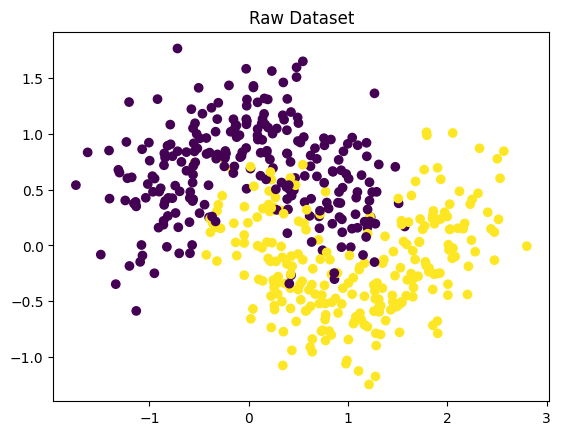

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_moons

# Create nonlinear dataset
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

# Visualize raw data
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Raw Dataset")
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,     # number of trees
    max_depth=5,          # control overfitting
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [6]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Feature Importances:", rf.feature_importances_)

Accuracy: 0.9

Confusion Matrix:
 [[43  0]
 [10 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.90        43
           1       1.00      0.82      0.90        57

    accuracy                           0.90       100
   macro avg       0.91      0.91      0.90       100
weighted avg       0.92      0.90      0.90       100

Feature Importances: [0.43329025 0.56670975]


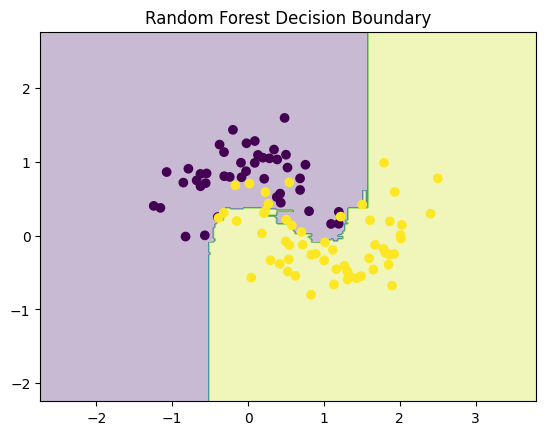

In [5]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = rf.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
plt.title("Random Forest Decision Boundary")
plt.show()